In [1]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import folddof
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pymanopt
import geomstats.visualization as visualization
import geomstats.backend as gs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import datashader as ds
from datashader.mpl_ext import dsshow
from data.datasets import _process_csv_row_for_global_pep


def angular_deviation(ang1, ang2, backend=np):
    diff = backend.abs(ang1 - ang2)
    return backend.minimum(diff, backend.pi*2-diff)


cmap_ = sns.color_palette("ch:s=.25,rot=-.25", as_cmap=True)

In [2]:
import torch, roma
from folddof import to_backbone, to_bb_mode
from folddof.utils import dihedral, planar_angle, opt_root_mean_square_deviation
from folddof.data import DEF_LOC


def get_manopt_cost_func(avg_loc_ca_ia1_wrt_n_ia1, label_coords):
    manifold = pymanopt.manifolds.SpecialOrthogonalGroup(3, k=avg_loc_ca_ia1_wrt_n_ia1.shape[0]+1)
    @pymanopt.function.pytorch(manifold)
    def cost_rmsd(fitting_rotations):
        fitting_coords = to_backbone(fitting_rotations[None], avg_loc_ca_ia1_wrt_n_ia1[None], mode=to_bb_mode.Pep_GlobalRots_IsoRots,
                                rot_repr_is_q=False,
                                clamp_loc_ca_ia1_wrt_n_ia1_sigma=None,
                                ).squeeze(0).flatten(0, 1)
        R_rp, t_rp = roma.rigid_points_registration(fitting_coords, label_coords)
        rp_fitting_coords = fitting_coords @ R_rp.T + t_rp
        rmsd = torch.sqrt(torch.square((label_coords-(rp_fitting_coords)).norm(dim=1)).mean())
        return rmsd
    return manifold, cost_rmsd


def get_phi_psi(bb_coords):
    '''NOTE: length dim is 0'''
    phi = dihedral(
                            bb_coords[:, 2][:-1],
                            bb_coords[:, 0][1:],
                            bb_coords[:, 1][1:],
                            bb_coords[:, 2][1:])
    psi = dihedral(
                            bb_coords[:, 0][:-1],
                            bb_coords[:, 1][:-1],
                            bb_coords[:, 2][:-1],
                            bb_coords[:, 0][1:])
    return phi, psi


In [3]:
df = pd.read_csv('../metadata/scope_metadata.csv', keep_default_na=False)

In [4]:
geo_issue_files = []
issue_files = []
is_trans_records = []
bb_rmsds = []
bb_rmsds_with_true_ca_ia1_wrt_n_ia1 = []
bb_rmsds_pymanopt = []
geodesic_rr_pymanopt = []
loc_ca_i_list = []
loc_o_i_list = []
loc_n_ia1_list = []
loc_ca_ia1_list = []
phi_list = []
psi_list = []
n_ca_c_angle_list = []
avg_re_phi_list = []
avg_re_psi_list = []
avg_re_n_ca_c_angle_list = []
avg_re_phi__list = []
avg_re_psi__list = []
avg_re_n_ca_c_angle__list = []
pymanopt_avg_re_phi_list = []
pymanopt_avg_re_psi_list = []
pymanopt_avg_re_n_ca_c_angle_list = []


for file in tqdm(df.processed_path):
    file_path = f"/home/zhu_zf/tools/FrameFlowZenodo/{file}"
    try:
        
        data = _process_csv_row_for_global_pep(file_path, return_bb_coords=True)

        c_n_length = (data['bb_coords'][:-1, 2]-data['bb_coords'][1:, 0]).norm(dim=1)
        mask_2 = c_n_length < 2
        if (~mask_2).any():
            geo_issue_files.append(file_path)
            continue

        is_trans_records.append(folddof.frame.PeptideUnitFrame.whether_is_trans(data['loc_ca_ia1_wrt_n_ia1_1']))
        global_rots = data['rotmats_1']
        global_trans = data['trans_1']
        ret_loc_ca_ia1_wrt_n_ia1 = data['loc_ca_ia1_wrt_n_ia1_1']
        avg_loc_ca_ia1_wrt_n_ia1 = folddof.frame.PeptideUnitFrame.to_avg_loc_ca_ia1_wrt_n_ia1(ret_loc_ca_ia1_wrt_n_ia1)
        avg_bb_coords = to_backbone(global_rots[None], avg_loc_ca_ia1_wrt_n_ia1[None], mode=to_bb_mode.Pep_GlobalRots_IsoRots,
                                rot_repr_is_q=False,
                                clamp_loc_ca_ia1_wrt_n_ia1_sigma=None,#3,
                                ).squeeze(0)
        avg_bb_coords_ = to_backbone(global_rots[None], ret_loc_ca_ia1_wrt_n_ia1[None], mode=to_bb_mode.Pep_GlobalRots_IsoRots,
                                rot_repr_is_q=False,
                                clamp_loc_ca_ia1_wrt_n_ia1_sigma=None,#3,
                                ).squeeze(0)
        label_bb_atoms = data['bb_coords'].flatten(0, 1)
        bb_rmsds.append(opt_root_mean_square_deviation(label_bb_atoms, avg_bb_coords.flatten(0, 1)).tolist())
        bb_rmsds_with_true_ca_ia1_wrt_n_ia1.append(opt_root_mean_square_deviation(label_bb_atoms, avg_bb_coords_.flatten(0, 1)).tolist())

        problem = pymanopt.Problem(*get_manopt_cost_func(avg_loc_ca_ia1_wrt_n_ia1, label_bb_atoms))
        optimizer = pymanopt.optimizers.ConjugateGradient("PolakRibiere", max_iterations=3, verbosity=0, log_verbosity=1) # NOTE: max_iterations=1 -> no optimization; thus to perform 2 steps of opt, we need to set max_iterations=3
        result = optimizer.run(problem, initial_point=global_rots.numpy())
        bb_rmsds_pymanopt.append(result.log['iterations']['cost'][-1].tolist())
        pymanopt_global_rots = torch.from_numpy(result.point)
        pymanopt_avg_bb_coords = to_backbone(pymanopt_global_rots[None], avg_loc_ca_ia1_wrt_n_ia1[None], mode=to_bb_mode.Pep_GlobalRots_IsoRots,
                                rot_repr_is_q=False,
                                clamp_loc_ca_ia1_wrt_n_ia1_sigma=None,#3,
                                ).squeeze(0)
        if abs(opt_root_mean_square_deviation(label_bb_atoms, pymanopt_avg_bb_coords.flatten(0, 1)).tolist() - bb_rmsds_pymanopt[-1]) > 1e-5:
            print(file, 'pymanopt rmsd issue')

        rrots = global_rots[:-1].transpose(1, 2) @ global_rots[1:]
        pymanopt_rrots = pymanopt_global_rots[:-1].transpose(1, 2) @ pymanopt_global_rots[1:]
        geodesic_rr_pymanopt.extend(roma.rotmat_geodesic_distance(rrots, pymanopt_rrots).tolist())

        phi, psi = get_phi_psi(data['bb_coords']); phi_list.append(phi.numpy()); psi_list.append(psi.numpy())
        avg_re_phi, avg_re_psi = get_phi_psi(avg_bb_coords); avg_re_phi_list.append(avg_re_phi.numpy()); avg_re_psi_list.append(avg_re_psi.numpy())
        avg_re_phi_, avg_re_psi_ = get_phi_psi(avg_bb_coords_); avg_re_phi__list.append(avg_re_phi_.numpy()); avg_re_psi__list.append(avg_re_psi_.numpy())
        pymanopt_avg_re_phi, pymanopt_avg_re_psi = get_phi_psi(pymanopt_avg_bb_coords); pymanopt_avg_re_phi_list.append(pymanopt_avg_re_phi.numpy()); pymanopt_avg_re_psi_list.append(pymanopt_avg_re_psi.numpy())

        n_ca_c_angle = planar_angle(data['bb_coords'][:, 0], data['bb_coords'][:, 1], data['bb_coords'][:, 2]); n_ca_c_angle_list.append(n_ca_c_angle.numpy())
        avg_re_n_ca_c_angle = planar_angle(avg_bb_coords[:, 0], avg_bb_coords[:, 1], avg_bb_coords[:, 2]); avg_re_n_ca_c_angle_list.append(avg_re_n_ca_c_angle.numpy())
        avg_re_n_ca_c_angle_ = planar_angle(avg_bb_coords_[:, 0], avg_bb_coords_[:, 1], avg_bb_coords_[:, 2]); avg_re_n_ca_c_angle__list.append(avg_re_n_ca_c_angle_.numpy())
        pymanopt_avg_re_n_ca_c_angle = planar_angle(pymanopt_avg_bb_coords[:, 0], pymanopt_avg_bb_coords[:, 1], pymanopt_avg_bb_coords[:, 2]); pymanopt_avg_re_n_ca_c_angle_list.append(pymanopt_avg_re_n_ca_c_angle.numpy())

        to_local_pos = lambda x: torch.einsum('lij,lj->li', global_rots[1:-1].transpose(-1, -2), x-global_trans[1:-1])
        loc_ca_i_list.append(to_local_pos(data['bb_coords'][:-1, 1]).numpy())
        loc_o_i_list.append(to_local_pos(data['bb_coords'][:-1, 3]).numpy())
        loc_n_ia1_list.append(to_local_pos(data['bb_coords'][1:, 0]).numpy())
        loc_ca_ia1_list.append(to_local_pos(data['bb_coords'][1:, 1]).numpy())

    except AssertionError as e:
        issue_files.append(file_path)



100%|██████████| 8761/8761 [15:56<00:00,  9.16it/s]


In [5]:
loc_ca_i_list = np.concatenate(loc_ca_i_list)
loc_o_i_list = np.concatenate(loc_o_i_list)
loc_n_ia1_list = np.concatenate(loc_n_ia1_list)
loc_ca_ia1_list = np.concatenate(loc_ca_ia1_list)

phi_list = np.concatenate(phi_list)
psi_list = np.concatenate(psi_list)
n_ca_c_angle_list = np.concatenate(n_ca_c_angle_list)
avg_re_phi_list = np.concatenate(avg_re_phi_list)
avg_re_psi_list = np.concatenate(avg_re_psi_list)
avg_re_n_ca_c_angle_list = np.concatenate(avg_re_n_ca_c_angle_list)
avg_re_phi__list = np.concatenate(avg_re_phi__list)
avg_re_psi__list = np.concatenate(avg_re_psi__list)
avg_re_n_ca_c_angle__list = np.concatenate(avg_re_n_ca_c_angle__list)
pymanopt_avg_re_phi_list = np.concatenate(pymanopt_avg_re_phi_list)
pymanopt_avg_re_psi_list = np.concatenate(pymanopt_avg_re_psi_list)
pymanopt_avg_re_n_ca_c_angle_list = np.concatenate(pymanopt_avg_re_n_ca_c_angle_list)

In [6]:
loc_ca_i_norm = np.linalg.norm(loc_ca_i_list, axis=1)
loc_n_ia1_norm = np.linalg.norm(loc_n_ia1_list, axis=1)
loc_o_i_norm = np.linalg.norm(loc_o_i_list, axis=1)
loc_ca_ia1_m_n_ia1_norm = np.linalg.norm(loc_ca_ia1_list-loc_n_ia1_list, axis=1)
loc_ca_ia1_m_avg_n_ia1_norm = np.linalg.norm(loc_ca_ia1_list-np.array(DEF_LOC['n_ia1'], dtype=loc_ca_ia1_list.dtype), axis=1)
norm_loc_ca_i = np.einsum('km,k->km', loc_ca_i_list, 1/loc_ca_i_norm)
norm_loc_o_i = np.einsum('km,k->km', loc_o_i_list, 1/loc_o_i_norm)
norm_loc_ca_ia1_m_n_ia1 = np.einsum('km,k->km', loc_ca_ia1_list-loc_n_ia1_list, 1/loc_ca_ia1_m_n_ia1_norm)

mask = (loc_ca_i_norm > 1) & (loc_ca_i_norm < 2) & (loc_n_ia1_norm > 1) & (loc_n_ia1_norm < 2) & (loc_ca_ia1_m_n_ia1_norm > 1) & (loc_ca_ia1_m_n_ia1_norm < 2) & (loc_o_i_norm > 1) & (loc_o_i_norm < 2)

In [7]:
"""
cis_pep_count = np.array([(~i).sum().tolist() for i in is_trans_records])


cis_pep_idx_loc = [torch.where(~i)[0] for i in is_trans_records]
cis_pep_proLen = [[i.shape[0]]*(~i).sum().tolist() for i in is_trans_records]
cis_pep_cisCount = np.concatenate([[(~i).sum().tolist()]*(~i).sum().tolist() for i in is_trans_records])
cis_pep_proLen_all = np.array([i.shape[0] for i in is_trans_records])
cis_pep_idx_loc_ = cis_pep_idx_loc
cis_pep_idx_loc = torch.cat(cis_pep_idx_loc).numpy()
cis_pep_proLen = np.concatenate(cis_pep_proLen)
length_mask = (cis_pep_proLen>=60) & (cis_pep_proLen<=128*2)
length_mask_all = (cis_pep_proLen_all>=60) & (cis_pep_proLen_all<=128*2)

length_with_gt1_cis_pep = np.concatenate([[L]*(i.shape[0]-1) for i, L, mask in zip(cis_pep_idx_loc_, [record.shape[0] for record in is_trans_records], length_mask_all) if (i.shape[0] > 1) and mask])
distance_between_2_cis_pep = torch.cat([(i[1:]-i[:-1]) for i, mask in zip(cis_pep_idx_loc_, length_mask_all) if (i.shape[0] > 1) and mask]).numpy()

num_of_cis_pep_with_gt1_cis_pep = np.concatenate([[i.shape[0]]*(i.shape[0]-1) for i, mask in zip(cis_pep_idx_loc_, length_mask_all) if (i.shape[0] > 1) and mask])
num_of_cis_pep_with_gt1_cis_pep.shape, distance_between_2_cis_pep.shape
"""
issue_files = [i[35:] for i in issue_files]
geo_issue_files = [i[35:] for i in geo_issue_files]

In [8]:
clean_df = df[(~df.processed_path.isin(issue_files+geo_issue_files))].reset_index(drop=True)#.seq_len.describe()
#assert (clean_df.seq_len == cis_pep_proLen_all).all()
#clean_df['cis_pep_count'] = cis_pep_count
clean_df['bb_rmsd'] = bb_rmsds
clean_df['bb_rmsd_with_true_ca_ia1'] = bb_rmsds_with_true_ca_ia1_wrt_n_ia1
clean_df['bb_rmsd_pymanopt'] = bb_rmsds_pymanopt

In [9]:
# clean_df.to_csv('../metadata/scope_metadata.clean.csv', index=False)

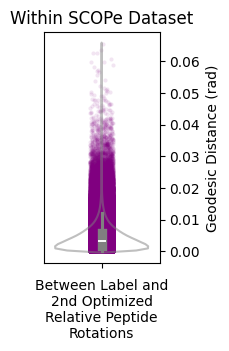

In [10]:
plt.figure(figsize=(1.5,3))
er = np.array(geodesic_rr_pymanopt)#np.sqrt(npzdata['geodesic_rr_opt'])*2
g = sns.stripplot(data=er, s=3, alpha=0.1, color='purple', orient='v', zorder=1)
g = sns.violinplot(data=er, fill=False, color='gray', zorder=2, alpha=0.5)
plt.title("Within SCOPe Dataset")
plt.xlabel('Between Label and\n2nd Optimized\nRelative Peptide\nRotations')
plt.ylabel('Geodesic Distance (rad)')
g.yaxis.set_label_position("right")
g.yaxis.tick_right()
plt.show()

In [11]:
head_num = 40000

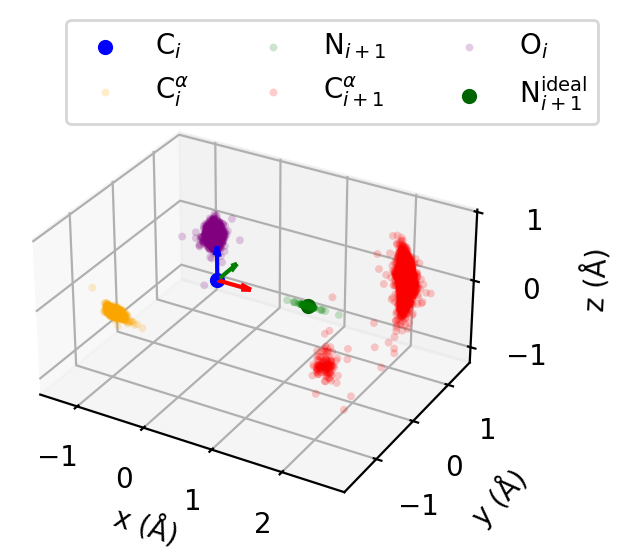

In [12]:
plt.figure(figsize=(3, 3), dpi=200)
axes = plt.axes(projection='3d')

s0 = axes.scatter3D([0], [0], [0], color='blue')
sN = axes.scatter3D([DEF_LOC['n_ia1'][0]], [DEF_LOC['n_ia1'][1]], [DEF_LOC['n_ia1'][2]], color='darkgreen')
s1 = axes.scatter3D(*loc_ca_i_list[mask][:head_num].transpose(1, 0), color='orange', alpha=.2, s=8, linewidth=0, zorder=1)
s2 = axes.scatter3D(*loc_n_ia1_list[mask][:head_num].transpose(1, 0), color='green', alpha=.2, s=8, linewidth=0, zorder=1)
s3 = axes.scatter3D(*loc_ca_ia1_list[mask][:head_num].transpose(1, 0), color='red', alpha=.2, s=8, linewidth=0, zorder=1)
s4 = axes.scatter3D(*loc_o_i_list[mask][:head_num].transpose(1, 0), color='purple', alpha=.2, s=8, linewidth=0, zorder=1)

q1 = axes.quiver([0], [0], [0], [1], [0], [0], length=0.5, normalize=1, color='red')
q2 = axes.quiver([0], [0], [0], [0], [1], [0], length=0.5, normalize=1, color='green')
q3 = axes.quiver([0], [0], [0], [0], [0], [1], length=0.5, normalize=1, color='blue')

q1.set_zorder(5)
q2.set_zorder(5)
q3.set_zorder(5)

axes.set_xlabel('x (Å)')
axes.set_ylabel('y (Å)')
axes.set_zlabel('z (Å)')
axes.set_zticks([-1,0,1])

axes.legend([s0, s1, s2, s3, s4, sN], [
            r'$\mathrm{C}_{i}$',
            r'$\mathrm{C}^{\alpha}_{i}$',
            r'$\mathrm{N}_{i+1}$',
            r'$\mathrm{C}^{\alpha}_{i+1}$',
            r'$\mathrm{O}_{i}$',
            r'$\mathrm{N}^{\mathrm{ideal}}_{i+1}$',
            ]
            , loc=(0.1,0.9), ncol=3)
#"""
xlim = axes.get_xlim3d()
ylim = axes.get_ylim3d()
zlim = axes.get_zlim3d()
axes.set_box_aspect((xlim[1]-xlim[0], ylim[1]-ylim[0], zlim[1]-zlim[0]))
#"""
plt.show()

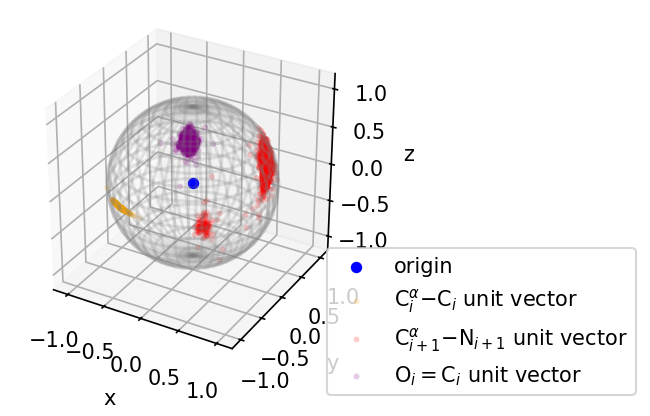

In [13]:
fig = plt.figure(figsize=(3, 3), dpi=150)
axes = fig.add_subplot(111, projection="3d")
s00 = visualization.plot(norm_loc_ca_i[mask][:1], ax=axes, space="S2", s=8, color='orange', alpha=.2, linewidth=0)
s0 = axes.scatter3D([0], [0], [0], color='blue')
s1 = axes.scatter3D(*norm_loc_ca_i[mask][1:][:head_num].transpose(1, 0), color='orange', s=8, alpha=.2, linewidth=0)
s2 = axes.scatter3D(*norm_loc_ca_ia1_m_n_ia1[mask][:head_num].transpose(1, 0), color='red', s=8, alpha=.2, linewidth=0)
s3 = axes.scatter3D(*norm_loc_o_i[mask][:head_num].transpose(1, 0), color='purple', s=8, alpha=.2, linewidth=0)

axes.legend([s0, s1, s2, s3], [
            r'origin',
            r'$\mathrm{C}^{\alpha}_{i}\mathrm{-C}_{i}$ unit vector',
            r'$\mathrm{C}^{\alpha}_{i+1}\mathrm{-N}_{i+1}$ unit vector',
            r'$\mathrm{O}_{i}=\mathrm{C}_{i}$ unit vector'], 
            loc=(0.9,-0.1), 
            ncol=1,
            )#loc='lower left')

axes.set_xlabel('x')
axes.set_ylabel('y')
axes.set_zlabel('z')
plt.show()


/tmp/ipykernel_4118859/1461298070.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_, y='Bond Type', x='Bond Length (Å)', palette=['orange', 'red', 'pink', 'purple'], linewidth=.5)


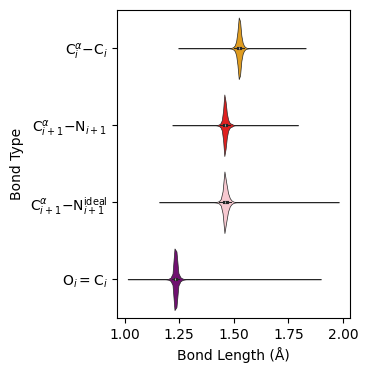

In [14]:
plt.figure(figsize=(3,4))
df_ = pd.DataFrame({
    r"$\mathrm{C}^{\alpha}_{i}\mathrm{-C}_{i}$": loc_ca_i_norm[mask],
    r"$\mathrm{C}^{\alpha}_{i+1}\mathrm{-N}_{i+1}$": loc_ca_ia1_m_n_ia1_norm[mask],
    r"$\mathrm{C}^{\alpha}_{i+1}\mathrm{-N}_{i+1}^{\mathrm{ideal}}$": loc_ca_ia1_m_avg_n_ia1_norm[mask],
    r"$\mathrm{O}_{i}=\mathrm{C}_{i}$": loc_o_i_norm[mask],
}).stack().reset_index(1).rename(columns={'level_1': 'Bond Type', 0: 'Bond Length (Å)'})
sns.violinplot(data=df_, y='Bond Type', x='Bond Length (Å)', palette=['orange', 'red', 'pink', 'purple'], linewidth=.5)
plt.show()

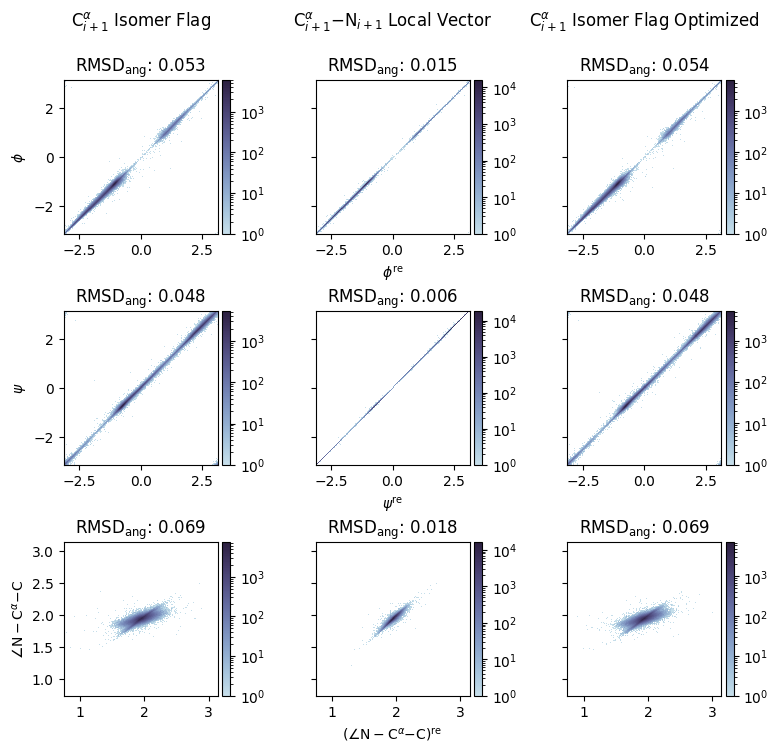

In [15]:
prefix = 'avg_' # avg_ manopt_
suffix = ''

diff_n_ca_c_angle = angular_deviation(n_ca_c_angle_list, avg_re_n_ca_c_angle_list)

diff_phi = angular_deviation(phi_list, avg_re_phi_list)
diff_psi = angular_deviation(psi_list, avg_re_psi_list)

data1 = pd.DataFrame({
    'phi': phi_list,
     prefix+'phi'+suffix: avg_re_phi_list,
    'psi': psi_list,
    prefix+'psi'+suffix: avg_re_psi_list,
    })
data2 = pd.DataFrame({
    'n_ca_c_angle': n_ca_c_angle_list,
     prefix+'n_ca_c_angle'+suffix: avg_re_n_ca_c_angle_list,
})

cmap = cmap_ # seismic viridis
fig, grid = plt.subplots(figsize=(9, 8), nrows=3, ncols=3)
#cbar_size="5%", cbar_pad="2%"

grid = grid.T

artist0 = dsshow(data1, ds.Point(prefix+'phi'+suffix, 'phi'), ds.count(), norm='log', cmap=cmap, aspect='equal', ax=grid[0,0], width_scale=3., height_scale=3.)
clb = plt.colorbar(artist0, cax=make_axes_locatable(grid[0,0]).append_axes("right", size="5%", pad="3%"))
artist1 = dsshow(data1, ds.Point(prefix+'psi'+suffix, 'psi'), ds.count(), norm='log', cmap=cmap, aspect='equal', ax=grid[0,1], width_scale=3., height_scale=3.)
clb = plt.colorbar(artist1, cax=make_axes_locatable(grid[0,1]).append_axes("right", size="5%", pad="3%"))
artist2 = dsshow(data2, ds.Point(prefix+'n_ca_c_angle'+suffix, 'n_ca_c_angle'), ds.count(), norm='log', cmap=cmap, aspect='equal', ax=grid[0,2], width_scale=3., height_scale=3.)
clb = plt.colorbar(artist2, cax=make_axes_locatable(grid[0,2]).append_axes("right", size="5%", pad="3%"))
grid[0,0].set_title(r'$\mathrm{C}^{\alpha}_{i+1}$'+' Isomer Flag\n\n$\mathrm{RMSD}_{\mathrm{ang}}$: %.3f' % np.sqrt((diff_phi**2).mean()))
grid[0,0].set_ylabel('$\phi$')
#grid[0,0].set_xlabel('$\phi^{\mathrm{re}}$')
grid[0,1].set_title('$\mathrm{RMSD}_{\mathrm{ang}}$: %.3f' % np.sqrt((diff_psi**2).mean()))
grid[0,1].set_ylabel('$\psi$')
#grid[0,1].set_xlabel('$\psi^{\mathrm{re}}$')
grid[0,2].set_title(r'$\mathrm{RMSD}_{\mathrm{ang}}$: ' + '%.3f' % np.sqrt((diff_n_ca_c_angle**2).mean()))
grid[0,2].set_ylabel(r'$\angle\mathrm{N-C}^{\alpha}\mathrm{-C}$')
#grid[0,2].set_xlabel(r'$(\angle\mathrm{N-C}^{\alpha}\mathrm{-C})^{\mathrm{re}}$')
grid[0,2].set_xlim([.74, (np.pi)])
grid[0,2].set_ylim([.74, (np.pi)])


prefix = 'avg_' # avg_ manopt_
suffix = '_wtca'

diff_n_ca_c_angle = angular_deviation(n_ca_c_angle_list, avg_re_n_ca_c_angle__list)

diff_phi = angular_deviation(phi_list, avg_re_phi__list)
diff_psi = angular_deviation(psi_list, avg_re_psi__list)

data1 = pd.DataFrame({
    'phi': phi_list,
     prefix+'phi'+suffix: avg_re_phi__list,
    'psi': psi_list,
    prefix+'psi'+suffix: avg_re_psi__list,
    })
data2 = pd.DataFrame({
    'n_ca_c_angle': n_ca_c_angle_list,
     prefix+'n_ca_c_angle'+suffix: avg_re_n_ca_c_angle__list,
})


artist0 = dsshow(data1, ds.Point(prefix+'phi'+suffix, 'phi'), ds.count(), norm='log', cmap=cmap, aspect='equal', ax=grid[1,0], width_scale=3., height_scale=3.) # grid[1,0].hist2d(data1[prefix+'phi'+suffix], data1['phi'], bins=100, cmin=1, norm=mpl.colors.LogNorm(), cmap=cmap)
clb = plt.colorbar(artist0, cax=make_axes_locatable(grid[1,0]).append_axes("right", size="5%", pad="3%"))
artist1 = dsshow(data1, ds.Point(prefix+'psi'+suffix, 'psi'), ds.count(), norm='log', cmap=cmap, aspect='equal', ax=grid[1,1], width_scale=3., height_scale=3.)
clb = plt.colorbar(artist1, cax=make_axes_locatable(grid[1,1]).append_axes("right", size="5%", pad="3%"))
artist2 = dsshow(data2, ds.Point(prefix+'n_ca_c_angle'+suffix, 'n_ca_c_angle'), ds.count(), norm='log', cmap=cmap, aspect='equal', ax=grid[1,2], width_scale=3., height_scale=3.)
clb = plt.colorbar(artist2, cax=make_axes_locatable(grid[1,2]).append_axes("right", size="5%", pad="3%"))
grid[1,0].set_title(r'$\mathrm{C}^{\alpha}_{i+1}\mathrm{-N}_{i+1}$ Local Vector'+'\n\n$\mathrm{RMSD}_{\mathrm{ang}}$: %.3f' % np.sqrt((diff_phi**2).mean()))
#grid[1,0].set_ylabel('$\phi$')
grid[1,0].set_yticklabels([])
grid[1,0].set_xlabel('$\phi^{\mathrm{re}}$')
grid[1,1].set_title('$\mathrm{RMSD}_{\mathrm{ang}}$: %.3f' % np.sqrt((diff_psi**2).mean()))
#grid[1,1].set_ylabel('$\psi$')
grid[1,1].set_yticklabels([])
grid[1,1].set_xlabel('$\psi^{\mathrm{re}}$')
grid[1,2].set_title(r'$\mathrm{RMSD}_{\mathrm{ang}}$: ' + '%.3f' % np.sqrt((diff_n_ca_c_angle**2).mean()))
#grid[1,2].set_ylabel(r'$\angle\mathrm{N-C}^{\alpha}\mathrm{-C}$')
grid[1,2].set_yticklabels([])
grid[1,2].set_xlabel(r'$(\angle\mathrm{N-C}^{\alpha}\mathrm{-C})^{\mathrm{re}}$')
grid[1,2].set_xlim([.74, (np.pi)])
grid[1,2].set_ylim([.74, (np.pi)])

prefix = 'manopt_' # avg_ manopt_
suffix = ''


diff_n_ca_c_angle = angular_deviation(n_ca_c_angle_list, pymanopt_avg_re_n_ca_c_angle_list)

diff_phi = angular_deviation(phi_list, pymanopt_avg_re_phi_list)
diff_psi = angular_deviation(psi_list, pymanopt_avg_re_psi_list)

data1 = pd.DataFrame({
    'phi': phi_list,
     prefix+'phi'+suffix: pymanopt_avg_re_phi_list,
    'psi': psi_list,
    prefix+'psi'+suffix: pymanopt_avg_re_psi_list,
    })
data2 = pd.DataFrame({
    'n_ca_c_angle': n_ca_c_angle_list,
     prefix+'n_ca_c_angle'+suffix: pymanopt_avg_re_n_ca_c_angle_list,
})


artist0 = dsshow(data1, ds.Point(prefix+'phi'+suffix, 'phi'), ds.count(), norm='log', cmap=cmap, aspect='equal', ax=grid[2,0], width_scale=3., height_scale=3.) # grid[2,0].hist2d(data1[prefix+'phi'+suffix], data1['phi'], bins=100, cmin=2, norm=mpl.colors.LogNorm(), cmap=cmap)
clb = plt.colorbar(artist0, cax=make_axes_locatable(grid[2,0]).append_axes("right", size="5%", pad="3%"))
artist1 = dsshow(data1, ds.Point(prefix+'psi'+suffix, 'psi'), ds.count(), norm='log', cmap=cmap, aspect='equal', ax=grid[2,1], width_scale=3., height_scale=3.)
clb = plt.colorbar(artist1, cax=make_axes_locatable(grid[2,1]).append_axes("right", size="5%", pad="3%"))
artist2 = dsshow(data2, ds.Point(prefix+'n_ca_c_angle'+suffix, 'n_ca_c_angle'), ds.count(), norm='log', cmap=cmap, aspect='equal', ax=grid[2,2], width_scale=3., height_scale=3.)
clb = plt.colorbar(artist2, cax=make_axes_locatable(grid[2,2]).append_axes("right", size="5%", pad="3%"))
grid[2,0].set_title(r'$\mathrm{C}^{\alpha}_{i+1}$'+' Isomer Flag Optimized\n\n$\mathrm{RMSD}_{\mathrm{ang}}$: %.3f' % np.sqrt((diff_phi**2).mean()))
#grid[2,0].set_ylabel('$\phi$')
grid[2,0].set_yticklabels([])
#grid[2,0].set_xlabel('$\phi^{\mathrm{re}}$')
grid[2,1].set_title('$\mathrm{RMSD}_{\mathrm{ang}}$: %.3f' % np.sqrt((diff_psi**2).mean()))
#grid[2,1].set_ylabel('$\psi$')
grid[2,1].set_yticklabels([])
#grid[2,1].set_xlabel('$\psi^{\mathrm{re}}$')
grid[2,2].set_title(r'$\mathrm{RMSD}_{\mathrm{ang}}$: ' + '%.3f' % np.sqrt((diff_n_ca_c_angle**2).mean()))
#grid[2,2].set_ylabel(r'$\angle\mathrm{N-C}^{\alpha}\mathrm{-C}$')
grid[2,2].set_yticklabels([])
#grid[2,2].set_xlabel(r'$(\angle\mathrm{N-C}^{\alpha}\mathrm{-C})^{\mathrm{re}}$')
grid[2,2].set_xlim([.74, (np.pi)])
grid[2,2].set_ylim([.74, (np.pi)])

plt.subplots_adjust(wspace=0.3, hspace=0.5)

plt.show()


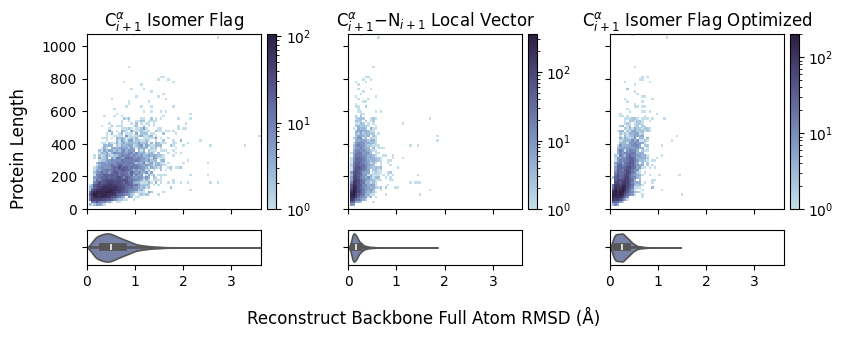

In [16]:
fig, grid = plt.subplots(figsize=(9, 3), nrows=2, ncols=3, sharey='row', sharex='col', gridspec_kw=dict(height_ratios=[5,1]))
cmap = cmap_

g = grid[0,0].hist2d(clean_df['bb_rmsd'], clean_df['seq_len'], bins=70, cmin=1, norm=mpl.colors.LogNorm(), cmap=cmap)
bins_args = (g[1], g[2])
#clb = plt.colorbar(g[3], cax=make_axes_locatable(grid[0,0]).append_axes("right", size="5%", pad="3%"))
fig.colorbar(g[3], ax=grid[:,0], shrink=0.758, anchor=(0.3, 1))
g = grid[0,1].hist2d(clean_df['bb_rmsd_with_true_ca_ia1'], clean_df['seq_len'], bins=bins_args, cmin=1, norm=mpl.colors.LogNorm(), cmap=cmap)
#clb = plt.colorbar(g[3], cax=make_axes_locatable(grid[0,1]).append_axes("right", size="5%", pad="3%"))
fig.colorbar(g[3], ax=grid[:,1], shrink=0.758, anchor=(.95, 1))
g = grid[0,2].hist2d(clean_df['bb_rmsd_pymanopt'], clean_df['seq_len'], bins=bins_args, cmin=1, norm=mpl.colors.LogNorm(), cmap=cmap)
#clb = plt.colorbar(g[3], cax=make_axes_locatable(grid[0,2]).append_axes("right", size="5%", pad="3%"))
fig.colorbar(g[3], ax=grid[:,2], shrink=0.758, anchor=(1.66, 1))

sns.violinplot(x=clean_df['bb_rmsd'].values, ax=grid[1,0], color=cmap(0.5), cut=0)
sns.violinplot(x=clean_df['bb_rmsd_with_true_ca_ia1'].values, ax=grid[1,1], color=cmap(0.5), cut=0)
sns.violinplot(x=clean_df['bb_rmsd_pymanopt'].values, ax=grid[1,2], color=cmap(0.5), cut=0)

grid[0,0].set_yticks([0,200,400,600,800,1000])
grid[1,0].set_xticks([0,1,2,3])
grid[1,1].set_xticks([0,1,2,3])
grid[1,2].set_xticks([0,1,2,3])

grid[0,0].set_title(r'$\mathrm{C}^{\alpha}_{i+1}$'+' Isomer Flag')
grid[0,1].set_title(r'$\mathrm{C}^{\alpha}_{i+1}\mathrm{-N}_{i+1}$ Local Vector')
grid[0,2].set_title(r'$\mathrm{C}^{\alpha}_{i+1}$'+' Isomer Flag Optimized')
fig.supxlabel("Reconstruct Backbone Full Atom RMSD (Å)", fontsize=12, y=-.1, )#x=0.5)
fig.supylabel("Protein Length", fontsize=12, x=0.04)
plt.subplots_adjust(wspace=0.5)
plt.show()